##### Class Continuous Assessment 01
##### Name- Harsh Mistry
##### PRN: 1262250487  
##### FY - MTech DSA  
##### Assessment Skill Code:


##### Importing Required Libraries

In [1]:
import os
import numpy as np
import pandas as pd
import librosa, librosa.display
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models

##### Loading Audio File, Resampling, Trimming, Extracting MFCC Features

In [2]:
DATA_DIR = "D:/Dialect_Dataset/data"
SR = 16000          # sample rate
DURATION = 3.0      # seconds per clip (pad/trim)
N_MFCC = 20

In [3]:
def load_audio(path, sr=SR, duration=DURATION):
    y, _ = librosa.load(path, sr=sr, mono=True)
    target_len = int(sr*duration)
    if len(y) < target_len:
        y = np.pad(y, (0, target_len-len(y)))
    else:
        y = y[:target_len]
    return y

##### Defining Extract_MFCC function to extract features from waveform, Returns Mean MFCCs over time

In [4]:
def extract_mfcc(y, sr=SR, n_mfcc=N_MFCC):
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    return np.mean(mfcc.T, axis=0)

##### Building Dataset, Extract MFCC using Function, Storing in rows and Labeling Data

In [5]:
rows = []
labels = []
print("Scanning dataset...")

for label in os.listdir(DATA_DIR):
    lang_path = os.path.join(DATA_DIR, label)
    if not os.path.isdir(lang_path):
        continue

    print(f"--> Processing {label}...")
    for file in os.listdir(lang_path):
        if file.endswith((".wav", ".mp3")):
            path = os.path.join(lang_path, file)
            try:
                y = load_audio(path)          # loads mp3/wav into waveform
                feat = extract_mfcc(y)        # MFCC extraction
                rows.append(feat)
                labels.append(label)
            except Exception as e:
                print("⚠️ Error:", e, " | File:", path)

X = np.array(rows)
y = np.array(labels)

print("Features shape:", X.shape)
print("Classes found:", set(labels))

Scanning dataset...
--> Processing Gujarati...


D:\anaconda3\Lib\site-packages\paramiko\pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "cipher": algorithms.TripleDES,
D:\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.Blowfish and will be removed from this module in 45.0.0.
  "class": algorithms.Blowfish,
D:\anaconda3\Lib\site-packages\paramiko\transport.py:243: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "class": algorithms.TripleDES,


--> Processing Hindi...
--> Processing Marathi...
Features shape: (77275, 20)
Classes found: {'Marathi', 'Hindi', 'Gujarati'}


##### Label Encoding

In [6]:
encoder = LabelEncoder()
y_enc = encoder.fit_transform(y)

##### Splits Data into Training and Testing Set

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y_enc, test_size=0.2, stratify=y_enc, random_state=42)

##### Scaling features using a SSc, Normalizing Feature to improve Training

In [8]:
scaler = StandardScaler() 
X_train = scaler.fit_transform(X_train) 
X_test = scaler.transform(X_test)

##### Training an SVM classifier on MFCCs using a rbf kernel and Accuracy Check

In [9]:
print("\n--- Training SVM ---")
svm = SVC(kernel="rbf", probability=True)
svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=encoder.classes_))


--- Training SVM ---
SVM Accuracy: 0.9928178582982854
              precision    recall  f1-score   support

    Gujarati       1.00      0.99      0.99      5287
       Hindi       0.99      1.00      0.99      5093
     Marathi       0.99      0.99      0.99      5075

    accuracy                           0.99     15455
   macro avg       0.99      0.99      0.99     15455
weighted avg       0.99      0.99      0.99     15455



##### Training using Random Forest and Accuracy Check

In [10]:
print("\n--- Training Random Forest ---")
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, target_names=encoder.classes_))


--- Training Random Forest ---
RF Accuracy: 0.9862180524102232
              precision    recall  f1-score   support

    Gujarati       0.99      0.99      0.99      5287
       Hindi       0.97      1.00      0.98      5093
     Marathi       0.99      0.98      0.98      5075

    accuracy                           0.99     15455
   macro avg       0.99      0.99      0.99     15455
weighted avg       0.99      0.99      0.99     15455



##### Plotting Confusion Matrix Heatmap

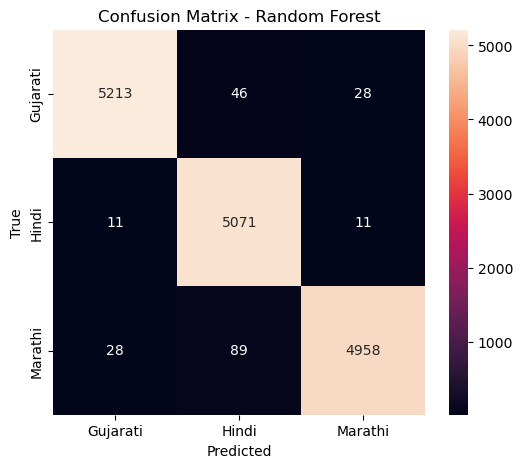

In [11]:
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Random Forest")
plt.show()

##### Building MFCC Spectogram + Labels with help of Librosa

In [12]:
print("\n--- Preparing CNN data ---")
def extract_mfcc_full(y, sr=SR, n_mfcc=N_MFCC):
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    return mfcc  # shape (n_mfcc, time)

X_dl = []
for label in os.listdir(DATA_DIR):
    lang_path = os.path.join(DATA_DIR, label)
    if not os.path.isdir(lang_path):
        continue
    for file in os.listdir(lang_path):
        if file.endswith(".wav") or file.endswith(".mp3"):
            path = os.path.join(lang_path, file)
            try:
                y = load_audio(path)
                mfcc = extract_mfcc_full(y)
                X_dl.append((mfcc, label))
            except Exception as e:
                print("Error:", e, path)

print("Total samples collected for CNN:", len(X_dl))


--- Preparing CNN data ---
Total samples collected for CNN: 77275


##### Padding MFCCs into Arrays, making sure to have equal length

In [13]:
# Safety check
if len(X_dl) == 0:
    raise ValueError("No audio files found — please check DATA_DIR and file formats")

# Find max time length among all MFCCs
max_len = max([mfcc.shape[1] for mfcc, _ in X_dl])

# Pad all MFCCs to this length and build arrays
X_data = np.array([
    np.pad(mfcc, ((0,0),(0,max_len-mfcc.shape[1])), mode="constant") 
    for mfcc, _ in X_dl
])
y_data = np.array([label for _, label in X_dl])

##### Label Encoding for CNN

In [15]:
y_data_enc = encoder.fit_transform(y_data)

##### Train/test split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data_enc, test_size=0.2, stratify=y_data_enc, random_state=42)

##### Add channel dimension

In [17]:
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print("DL input shape:", X_train.shape)

DL input shape: (61820, 20, 94, 1)


##### Defining Feature extraction and Classification Layers for CNN Model

In [18]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation="relu", input_shape=X_train.shape[1:]),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(len(encoder.classes_), activation="softmax")
])

D:\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


##### Training the model with suitable Optimizer and Loss Function

In [19]:
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
history = model.fit(X_train, y_train, epochs=15, batch_size=32, validation_split=0.2)

Epoch 1/15
1546/1546 ━━━━━━━━━━━━━━━━━━━━ 158s 99ms/step - accuracy: 0.8307 - loss: 0.7064 - val_accuracy: 0.9729 - val_loss: 0.0797
Epoch 2/15
1546/1546 ━━━━━━━━━━━━━━━━━━━━ 149s 96ms/step - accuracy: 0.9548 - loss: 0.1349 - val_accuracy: 0.9590 - val_loss: 0.1001
Epoch 3/15
1546/1546 ━━━━━━━━━━━━━━━━━━━━ 161s 104ms/step - accuracy: 0.9669 - loss: 0.0989 - val_accuracy: 0.9798 - val_loss: 0.0627
Epoch 4/15
1546/1546 ━━━━━━━━━━━━━━━━━━━━ 158s 102ms/step - accuracy: 0.9753 - loss: 0.0755 - val_accuracy: 0.9850 - val_loss: 0.0451
Epoch 5/15
1546/1546 ━━━━━━━━━━━━━━━━━━━━ 182s 89ms/step - accuracy: 0.9784 - loss: 0.0627 - val_accuracy: 0.9797 - val_loss: 0.0671
Epoch 6/15
1546/1546 ━━━━━━━━━━━━━━━━━━━━ 147s 95ms/step - accuracy: 0.9780 - loss: 0.0647 - val_accuracy: 0.9846 - val_loss: 0.0488
Epoch 7/15
1546/1546 ━━━━━━━━━━━━━━━━━━━━ 140s 90ms/step - accuracy: 0.9836 - loss: 0.0501 - val_accuracy: 0.9845 - val_loss: 0.0463
Epoch 8/15
1546/1546 ━━━━━━━━━━━━━━━━━━━━ 156s 101ms/step - accurac

##### Evaluating CNN Model

In [24]:
cnn_pred = model.predict(X_test)
cnn_pred_classes = cnn_pred.argmax(axis=1)
print(classification_report(y_test, cnn_pred_classes, target_names=encoder.classes_))

483/483 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step
              precision    recall  f1-score   support

    Gujarati       1.00      0.98      0.99      5287
       Hindi       0.98      1.00      0.99      5093
     Marathi       0.99      0.99      0.99      5075

    accuracy                           0.99     15455
   macro avg       0.99      0.99      0.99     15455
weighted avg       0.99      0.99      0.99     15455



##### Visualizing Misclassification using Confusion Matrix

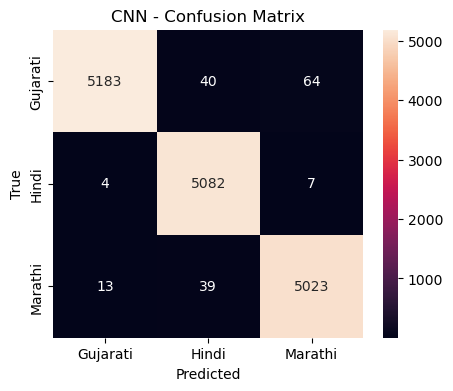

In [25]:
cm_cnn = confusion_matrix(y_test, cnn_pred_classes)
plt.figure(figsize=(5,4))
sns.heatmap(cm_cnn, annot=True, fmt="d", xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title("CNN - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

##### Evaluating the Model Accuracy

In [20]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("CNN Test Accuracy:", test_acc)

483/483 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - accuracy: 0.9889 - loss: 0.0545
CNN Test Accuracy: 0.9891944527626038


##### Defining a Inference Function to pass a new audio file for predicting Output

In [21]:
def predict_file(path, method="rf"):
    y = load_audio(path)
    if method == "rf":
        feat = extract_mfcc(y).reshape(1, -1)
        feat = scaler.transform(feat)
        pred = rf.predict(feat)[0]
        return encoder.inverse_transform([pred])[0]
    elif method == "cnn":
        mfcc = extract_mfcc_full(y)
        mfcc_pad = np.pad(mfcc, ((0,0),(0,max_len-mfcc.shape[1])), mode="constant")
        mfcc_pad = mfcc_pad[np.newaxis, ..., np.newaxis]
        pred = model.predict(mfcc_pad).argmax()
        return encoder.inverse_transform([pred])[0]

##### Predicting the Final Output

In [22]:
print(predict_file("D:/Dialect_Dataset/data/Hindi/1.mp3", method="rf"))

Hindi


In [29]:
print(predict_file("D:/Dialect_Dataset/data/Gujarati/285.mp3", method="rf"))

Gujarati


In [30]:
print(predict_file("D:/Dialect_Dataset/data/Marathi/5.mp3", method="rf"))

Marathi


##### Predicting output on custom Recordings

In [51]:
custom_path = "C:/Users/harsh/OneDrive/Documents/Sound Recordings/Marathi_Recording2.mp3"

In [52]:
def predict_custom_cnn(path):
    y = load_audio(path)
    mfcc = extract_mfcc_full(y)

    # Pad to same length as training data
    mfcc_pad = np.pad(mfcc, ((0,0),(0,max_len-mfcc.shape[1])), mode="constant")
    mfcc_pad = mfcc_pad[np.newaxis, ..., np.newaxis]

    pred = model.predict(mfcc_pad)
    pred_class = pred.argmax(axis=1)[0]

    return encoder.inverse_transform([pred_class])[0]

print("CNN Prediction:", predict_custom_cnn(custom_path))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step
CNN Prediction: Marathi
